#  Import Library & Load data

In [4]:
import pandas as pd
import jsonlines
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

with jsonlines.open("../data/raw/raw_dataset.jsonl") as reader:
    data = list(reader)

df = pd.DataFrame(data)
print(f"Total samples: {len(df)}")
df.head()

Total samples: 11984


,text,label
0,I noticed a charge on my account that I wasn't...,billing
1,Can you explain why there's an extra fee on my...,billing
2,"I looked at my payment history, and it seems l...",billing
3,"Hey, I got my invoice and it's way higher than...",billing
4,I think I'm being charged for two subscription...,billing


label
technical       2000
cancellation    2000
complaint       2000
api             2000
upgrade         1999
billing         1985
Name: count, dtype: int64


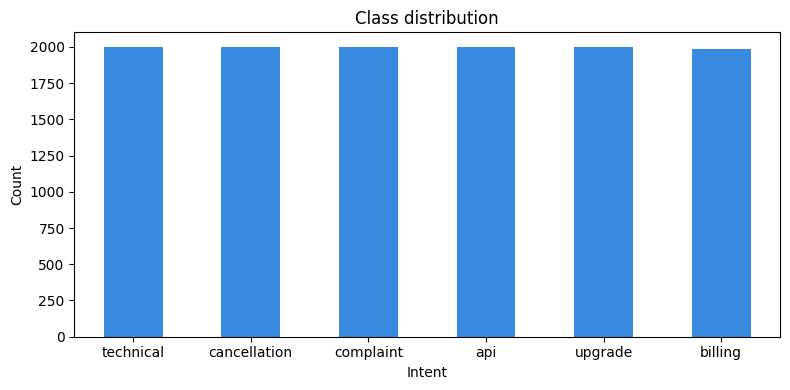

In [5]:
dist = df["label"].value_counts()
print(dist)

plt.figure(figsize=(8, 4))
dist.plot(kind="bar", color="#378ADD")
plt.title("Class distribution")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
duplicates = df[df.duplicated(subset=["text", "label"])]
print(f"Duplicate rows: {len(duplicates)}")
duplicates.head()

Duplicate rows: 291


,text,label
378,Why am I being charged for a service I didn't ...,billing
426,My last bill was way higher than usual. What’s...,billing
477,Why am I being billed for a service I didn’t use?,billing
530,"I was promised a discount, but it's not reflec...",billing
796,I think I was billed for a service I didn't us...,billing


In [7]:
duplicates["label"].value_counts()

label
cancellation    128
complaint        51
upgrade          41
api              32
technical        26
billing          13
Name: count, dtype: int64

In [8]:
df = df.drop_duplicates()

In [9]:
dist = df["label"].value_counts()
print(dist)

label
technical       1974
billing         1972
api             1968
upgrade         1958
complaint       1949
cancellation    1872
Name: count, dtype: int64


In [12]:
duplicates = df[df.duplicated(subset=["text", "label"])]
duplicates

,text,label


               count  mean   std   min   25%   50%   75%    max
label                                                          
api           1968.0  76.1  13.0  40.0  67.0  75.0  84.0  141.0
billing       1972.0  76.4  11.8  38.0  68.0  76.0  84.0  116.0
cancellation  1872.0  60.3   9.5  33.0  54.0  60.0  66.0   96.0
complaint     1949.0  67.7   9.9  40.0  61.0  67.0  74.0  101.0
technical     1974.0  71.6  10.0  41.0  65.0  71.0  78.0  119.0
upgrade       1958.0  72.2  12.3  32.0  64.0  72.0  80.0  117.0


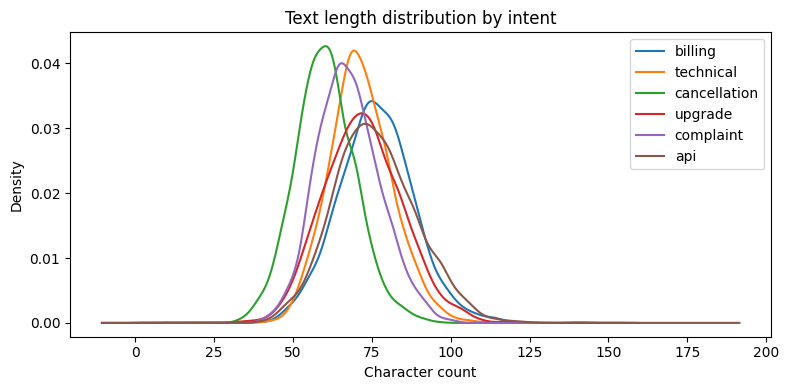

In [13]:
df["length"] = df["text"].str.len()

print(df.groupby("label")["length"].describe().round(1))

plt.figure(figsize=(8, 4))
for label in df["label"].unique():
    subset = df[df["label"] == label]["length"]
    subset.plot(kind="kde", label=label)
plt.title("Text length distribution by intent")
plt.xlabel("Character count")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
empty    = df[df["text"].str.strip() == ""]
too_short = df[df["length"] < 10]

print(f"Empty  : {len(empty)}")
print(f"Too short (<10 chars): {len(too_short)}")
too_short

Empty  : 0
Too short (<10 chars): 0


,text,label,length


In [15]:
valid_labels = {"billing","technical","cancellation","upgrade","complaint","api"}
invalid = df[~df["label"].isin(valid_labels)]
print(f"Invalid labels: {len(invalid)}")
invalid

Invalid labels: 0


,text,label,length


In [16]:
for label in sorted(valid_labels):
    print(f"\n{'─'*40}")
    print(f"[{label.upper()}]")
    samples = df[df["label"] == label].sample(3)["text"].tolist()
    for s in samples:
        print(f"  • {s}")


────────────────────────────────────────
[API]
  • Can I use the API from a different IP address, or does it need to be whitelisted?
  • I keep getting timeout errors when I try to fetch data from the API; what should I do?
  • The webhook I set up isn’t triggering. Can you check if there's an issue on your end?

────────────────────────────────────────
[BILLING]
  • I'm really confused about the different charges on my invoice and need clarification.
  • I was under the impression that my plan included unlimited data, but my bill suggests otherwise.
  • I was told there would be no charge for the trial period, but I see a fee. Why?

────────────────────────────────────────
[CANCELLATION]
  • Cancellation of my subscription is required; please assist.
  • This is my final request to cancel my account, please proceed.
  • Please take care of my cancellation request.

────────────────────────────────────────
[COMPLAINT]
  • Your service used to be great, but now it feels like no one car

In [17]:
print("_"*40)
print("DATA QUALITY SUMMARY")
print("_"*40)
print(f"Total samples    : {len(df)}")
print(f"Duplicates       : {len(duplicates)}")
print(f"Empty text       : {len(empty)}")
print(f"Too short        : {len(too_short)}")
print(f"Invalid labels   : {len(invalid)}")
print(f"Balanced classes : {dist.min() == dist.max()}")
print("_"*40)

if len(duplicates) == 0 and len(empty) == 0 and len(invalid) == 0:
    print("Data is clean — ready for cleaning script")
else:
    print("Issues found")

________________________________________
DATA QUALITY SUMMARY
________________________________________
Total samples    : 11693
Duplicates       : 0
Empty text       : 0
Too short        : 0
Invalid labels   : 0
Balanced classes : False
________________________________________
Data is clean — ready for cleaning script


In [19]:
df.to_json("../data/processed/clean_dataset.jsonl", orient="records", lines=True, force_ascii=False)